In [2]:
# 1. Import necessary libraries
import pandas as pd
import numpy as np
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [3]:
# 2. Load the dataset
# fetch_california_housing returns a dictionary-like object
housing_data = fetch_california_housing()

# Create a DataFrame for features
df = pd.DataFrame(housing_data.data, columns=housing_data.feature_names)

# Add the target variable (Median House Value)
df['MedHouseVal'] = housing_data.target

# Display the first few rows
print("First 5 rows of the dataset:")
print(df.head())

First 5 rows of the dataset:
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseVal  
0    -122.23        4.526  
1    -122.22        3.585  
2    -122.24        3.521  
3    -122.25        3.413  
4    -122.25        3.422  


In [4]:
# 3. Exploratory Data Analysis (EDA)
print("\nDataset Shape:", df.shape)

# Check data types and missing values
print("\nData Info:")
print(df.info())

# Check for missing values
print("\nMissing Values:")
print(df.isnull().sum())

# Summary statistics
print("\nStatistical Summary:")
print(df.describe())


Dataset Shape: (20640, 9)

Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB
None

Missing Values:
MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64

Statistical Summary:
             MedInc      HouseAge      AveRooms     AveBedrms    Population  \
count  20640.000000  20640.000000  20640.000000  20640.000000 

In [5]:
# 4. Separate Features and Target
X = df.drop("MedHouseVal", axis=1)  # Features
y = df["MedHouseVal"]               # Target variable


In [6]:
# 5. Train-Test Split
# Splitting 80% data for training and 20% for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("\nTraining set size:", X_train.shape)
print("Testing set size:", X_test.shape)



Training set size: (16512, 8)
Testing set size: (4128, 8)


In [7]:
# 6. Train Random Forest Regressor
# n_estimators=100 means we are using 100 decision trees
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)


RandomForestRegressor(random_state=42)

In [8]:
# 7. Make Predictions
y_pred = model.predict(X_test)


In [9]:
# 8. Evaluate Model
# Since this is a regression task, we use MSE and R2 Score
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("\nModel Evaluation:")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R-squared Score: {r2:.4f}")


Model Evaluation:
Mean Squared Error (MSE): 0.2554
Root Mean Squared Error (RMSE): 0.5053
R-squared Score: 0.8051


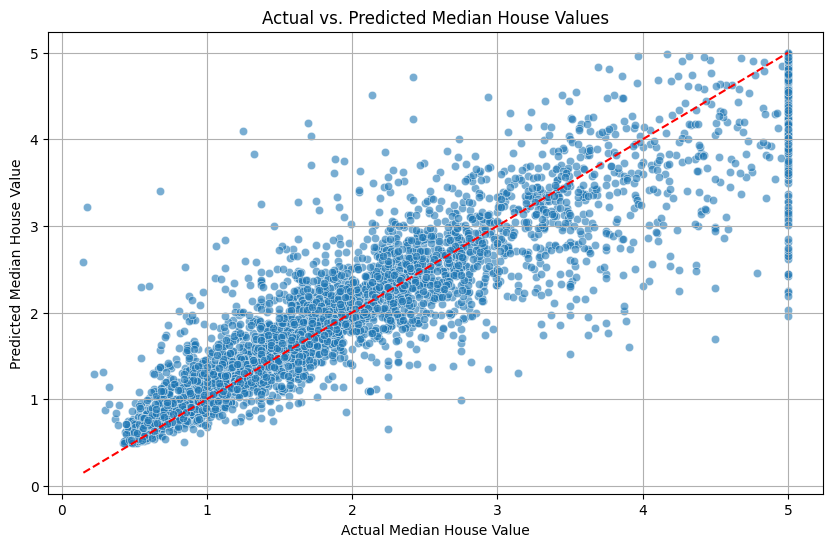

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# 9. Visualize Model Performance: Actual vs. Predicted Values
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual Median House Value')
plt.ylabel('Predicted Median House Value')
plt.title('Actual vs. Predicted Median House Values')
plt.grid(True)
plt.show()

/tmp/ipykernel_15275/1217064048.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')


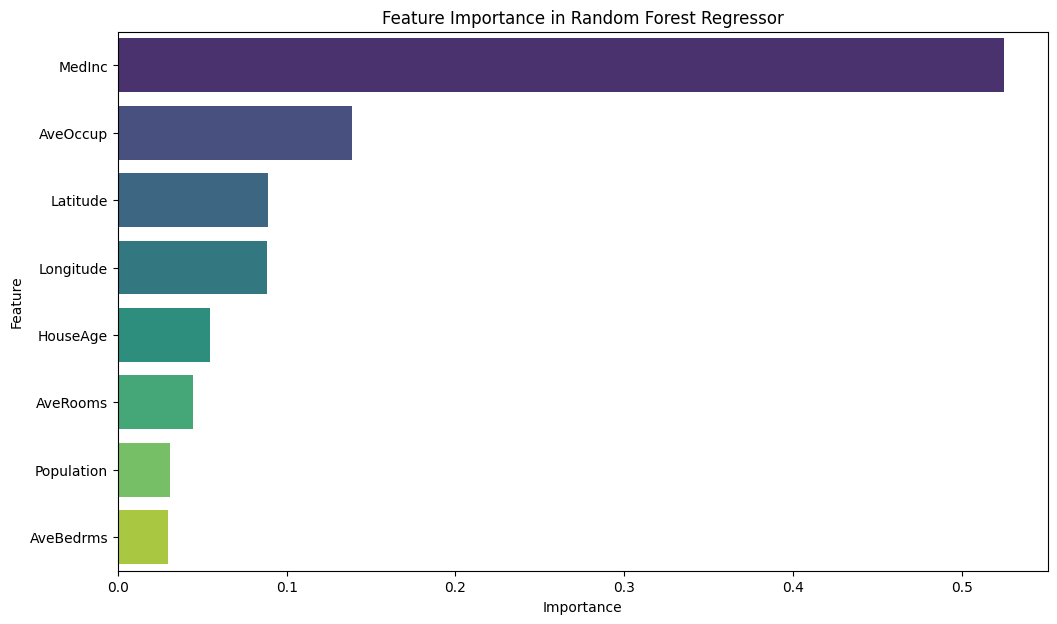

In [11]:
# 10. Visualize Feature Importance
feature_importances = model.feature_importances_
features = X.columns

importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': feature_importances
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(12, 7))
sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')
plt.title('Feature Importance in Random Forest Regressor')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

In [13]:
# 11. Predict on New Data
# Example: Creating a new house record with average values from the dataset
columns = X.columns
new_house = pd.DataFrame([[8.3, 41.0, 6.9, 1.0, 322.0, 2.5, 37.8, -122.2]],
                         columns=columns)

predicted_price = model.predict(new_house)
print(f"\nPredicted Median House Value for new data: ${predicted_price[0]*100000:.2f}")


Predicted Median House Value for new data: $442297.51
